<a href="https://colab.research.google.com/github/mmallare/ECGR4106/blob/main/ecgr4106_homework4b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import time
import math
import matplotlib.pyplot as plt
import random
import re
import matplotlib.ticker as ticker
import torch.nn.functional as F
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
from torch.utils.data import DataLoader, Dataset
import sys
import subprocess
import copy

try:
    import nltk
except ImportError:
    print("NLTK library not found. Installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/vast_english_french.txt'

with open(DATA_PATH, 'r') as file:
  content = file.read()
  # print(content)

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        encoding[:, 0::2] = torch.sin(position * div_term)
        encoding[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("encoding", encoding.unsqueeze(0))

    def forward(self, x):
        return x + self.encoding[:, : x.size(1)].detach()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_kb(model):
    return count_parameters(model) * 4 / 1024

In [ ]:
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

N_EPOCHS = 50
PATIENCE = 8
HIDDEN_SIZE = 128
LEARNING_RATE = 0.001
TEACHER_FORCING_RATIO = 0.5
N_QUALITATIVE_EXAMPLES = 5
MAX_GEN_LENGTH = 20

In [ ]:
def normalize_string(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"([.!?,])", r" \1 ", s)
    s = re.sub(r"[^a-z\u00e0-\u00f6\u00f8-\u00ff0-9'\-.,!?\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def load_pairs(text_content: str, reverse: bool = False):
    pairs = []
    for raw_line in text_content.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        parts = line.split("\t")
        if len(parts) < 2:
            parts = line.split(",")
        if len(parts) < 2:
            continue
        eng, fr = normalize_string(parts[0]), normalize_string(parts[1])
        if not eng or not fr:
            continue
        pairs.append((fr, eng) if reverse else (eng, fr))
    return pairs


def split_pairs(pairs, val_fraction=0.2, seed=42):
    rng = random.Random(seed)
    shuffled = pairs[:]
    rng.shuffle(shuffled)
    n_val = int(len(shuffled) * val_fraction)
    return shuffled[n_val:], shuffled[:n_val]


def compute_max_length(pairs):
    longest = 0
    for a, b in pairs:
        longest = max(longest, len(a.split(" ")), len(b.split(" ")))
    return longest + 1


class Vocabulary:
    def __init__(self):
        self.word2index = {"<PAD>": PAD_token, "<SOS>": SOS_token,
                            "<EOS>": EOS_token, "<UNK>": UNK_token}
        self.index2word = {v: k for k, v in self.word2index.items()}
        self.word_count = {}
        self.n_words = 4

    def add_sentence(self, sentence):
        for word in sentence.split(" "):
            if word:
                self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            self.word_count[word] += 1

    def indices_from_sentence(self, sentence):
        return [self.word2index.get(w, UNK_token) for w in sentence.split(" ") if w]


def sentence_to_tensor(vocab, sentence):
    indices = vocab.indices_from_sentence(sentence) + [EOS_token]
    return torch.tensor(indices, dtype=torch.long, device=device).view(-1, 1)


def indices_to_words(vocab, indices):
    return [vocab.index2word.get(i, "<UNK>") for i in indices]


class TranslationPairDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs, self.src_vocab, self.tgt_vocab = pairs, src_vocab, tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sentence, tgt_sentence = self.pairs[idx]
        return (sentence_to_tensor(self.src_vocab, src_sentence),
                sentence_to_tensor(self.tgt_vocab, tgt_sentence))


def make_dataloader(pairs, src_vocab, tgt_vocab, shuffle):
    return DataLoader(TranslationPairDataset(pairs, src_vocab, tgt_vocab),
                       batch_size=1, shuffle=shuffle)


In [ ]:
# baselines
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_token, hidden):
        embedded = self.embedding(input_token).view(1, 1, -1)
        return self.gru(embedded, hidden)

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.3):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_token, hidden):
        embedded = F.relu(self.dropout(self.embedding(input_token).view(1, 1, -1)))
        output, hidden = self.gru(embedded, hidden)
        return F.log_softmax(self.out(output[0]), dim=1), hidden


class AttnDecoderRNN(nn.Module):

    def __init__(self, hidden_size, output_size, max_length, dropout_p=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.max_length = max_length
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.dropout = nn.Dropout(dropout_p)
        self.attn = nn.Linear(hidden_size * 2, max_length)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_token, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input_token).view(1, 1, -1))
        attn_weights = F.softmax(self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)
        attn_applied = torch.bmm(attn_weights.unsqueeze(0), encoder_outputs.unsqueeze(0))
        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = F.relu(self.attn_combine(output).unsqueeze(0))
        output, hidden = self.gru(output, hidden)
        return F.log_softmax(self.out(output[0]), dim=1), hidden, attn_weights

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


def compute_loss_rnn(input_tensor, target_tensor, encoder, decoder, criterion,
                      use_attention, max_length, teacher_forcing_ratio,
                      encoder_optimizer=None, decoder_optimizer=None, train=False):
    encoder_hidden = encoder.init_hidden()
    if train:
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

    input_length, target_length = input_tensor.size(0), target_tensor.size(0)
    loss = 0.0

    if use_attention:
        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]
    else:
        encoder_outputs = None
        for ei in range(input_length):
            _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden
    use_tf = random.random() < teacher_forcing_ratio

    for di in range(target_length):
        if use_attention:
            decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
        else:
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        loss = loss + criterion(decoder_output, target_tensor[di])
        if use_tf:
            decoder_input = target_tensor[di].detach().view(1, 1)
        else:
            _, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)
            if decoder_input.item() == EOS_token:
                break

    if train:
        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
    return loss.item() / target_length


def run_epoch_rnn(dataloader, encoder, decoder, criterion, use_attention, max_length,
                   teacher_forcing_ratio, encoder_optimizer=None, decoder_optimizer=None,
                   train=True):
    total_loss = 0.0
    for input_tensor, target_tensor in dataloader:
        input_tensor, target_tensor = input_tensor[0].to(device), target_tensor[0].to(device)
        if train:
            loss = compute_loss_rnn(input_tensor, target_tensor, encoder, decoder, criterion,
                                     use_attention, max_length, teacher_forcing_ratio,
                                     encoder_optimizer, decoder_optimizer, train=True)
        else:
            with torch.no_grad():
                loss = compute_loss_rnn(input_tensor, target_tensor, encoder, decoder, criterion,
                                         use_attention, max_length, teacher_forcing_ratio=1.0, train=False)
        total_loss += loss
    return total_loss / max(len(dataloader), 1)


def generate_rnn(input_tensor, encoder, decoder, use_attention, max_length, max_gen_length=20):
    with torch.no_grad():
        encoder_hidden = encoder.init_hidden()
        input_length = input_tensor.size(0)
        if use_attention:
            encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)
            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
                encoder_outputs[ei] = encoder_output[0, 0]
        else:
            encoder_outputs = None
            for ei in range(input_length):
                _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        predicted_indices = []

        for _ in range(max_gen_length):
            if use_attention:
                decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
            else:
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            _, topi = decoder_output.topk(1)
            idx = topi.item()
            if idx == EOS_token:
                break
            predicted_indices.append(idx)
            decoder_input = topi.squeeze().detach().view(1, 1)
    return predicted_indices


def evaluate_dataset_rnn(pairs, src_vocab, tgt_vocab, encoder, decoder, use_attention,
                          max_length, n_examples=5, max_gen_length=20):
    encoder.eval(); decoder.eval()
    chencherry = SmoothingFunction()
    correct, total_bleu, examples = 0, 0.0, []

    for i, (src_sentence, tgt_sentence) in enumerate(pairs):
        src_tensor = sentence_to_tensor(src_vocab, src_sentence)
        target_words = tgt_sentence.split(" ")
        pred_indices = generate_rnn(src_tensor, encoder, decoder, use_attention, max_length, max_gen_length)
        pred_words = indices_to_words(tgt_vocab, pred_indices)
        is_match = pred_words == target_words
        correct += int(is_match)
        bleu = sentence_bleu([target_words], pred_words, smoothing_function=chencherry.method1)
        total_bleu += bleu
        if i < n_examples:
            examples.append((src_sentence, tgt_sentence, " ".join(pred_words), is_match, bleu))

    n = max(len(pairs), 1)
    encoder.train(); decoder.train()
    return {"accuracy": correct / n, "bleu": total_bleu / n, "examples": examples}


In [ ]:
# Transformer encoder-decoder
def generate_square_subsequent_mask(size):
    return torch.triu(torch.full((size, size), float("-inf"), device=device), diagonal=1)


class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, hidden_size, n_layers, n_heads, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.src_embedding = nn.Embedding(src_vocab_size, hidden_size)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size, nhead=n_heads, batch_first=True, dropout=dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size, nhead=n_heads, batch_first=True, dropout=dropout
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)

        self.fc_out = nn.Linear(hidden_size, tgt_vocab_size)

    def encode(self, src):
        src_emb = self.pos_encoder(self.src_embedding(src))
        return self.transformer_encoder(src_emb)

    def decode(self, tgt, memory, tgt_mask=None):
        tgt_emb = self.pos_encoder(self.tgt_embedding(tgt))
        out = self.transformer_decoder(tgt_emb, memory, tgt_mask=tgt_mask)
        return self.fc_out(out)

    def forward(self, src, tgt_input):
        memory = self.encode(src)
        tgt_mask = generate_square_subsequent_mask(tgt_input.size(1))
        return self.decode(tgt_input, memory, tgt_mask)


def compute_loss_transformer(input_tensor, target_tensor, model, criterion,
                              optimizer=None, train=False):
    src = input_tensor.view(1, -1)
    tgt_full = target_tensor.view(1, -1)

    sos = torch.tensor([[SOS_token]], device=device)
    decoder_input = torch.cat([sos, tgt_full[:, :-1]], dim=1)

    if train:
        optimizer.zero_grad()

    logits = model(src, decoder_input)
    loss = criterion(logits.view(-1, logits.size(-1)), tgt_full.view(-1))

    if train:
        loss.backward()
        optimizer.step()
    return loss.item()


def run_epoch_transformer(dataloader, model, criterion, optimizer=None, train=True):
    total_loss = 0.0
    for input_tensor, target_tensor in dataloader:
        input_tensor, target_tensor = input_tensor[0].to(device), target_tensor[0].to(device)
        if train:
            loss = compute_loss_transformer(input_tensor, target_tensor, model, criterion, optimizer, train=True)
        else:
            with torch.no_grad():
                loss = compute_loss_transformer(input_tensor, target_tensor, model, criterion, train=False)
        total_loss += loss
    return total_loss / max(len(dataloader), 1)


def generate_transformer(input_tensor, model, max_gen_length=20):
    model.eval()
    with torch.no_grad():
        src = input_tensor.view(1, -1)
        memory = model.encode(src)
        ys = torch.tensor([[SOS_token]], device=device)
        predicted_indices = []
        for _ in range(max_gen_length):
            tgt_mask = generate_square_subsequent_mask(ys.size(1))
            out = model.decode(ys, memory, tgt_mask)
            next_token = out[:, -1, :].argmax(dim=-1).item()
            if next_token == EOS_token:
                break
            predicted_indices.append(next_token)
            ys = torch.cat([ys, torch.tensor([[next_token]], device=device)], dim=1)
    model.train()
    return predicted_indices


def evaluate_dataset_transformer(pairs, src_vocab, tgt_vocab, model, n_examples=5, max_gen_length=20):
    model.eval()
    chencherry = SmoothingFunction()
    correct, total_bleu, examples = 0, 0.0, []

    for i, (src_sentence, tgt_sentence) in enumerate(pairs):
        src_tensor = sentence_to_tensor(src_vocab, src_sentence)
        target_words = tgt_sentence.split(" ")
        pred_indices = generate_transformer(src_tensor, model, max_gen_length)
        pred_words = indices_to_words(tgt_vocab, pred_indices)
        is_match = pred_words == target_words
        correct += int(is_match)
        bleu = sentence_bleu([target_words], pred_words, smoothing_function=chencherry.method1)
        total_bleu += bleu
        if i < n_examples:
            examples.append((src_sentence, tgt_sentence, " ".join(pred_words), is_match, bleu))

    n = max(len(pairs), 1)
    model.train()
    return {"accuracy": correct / n, "bleu": total_bleu / n, "examples": examples}


In [ ]:
def print_qualitative_examples(direction_label, model_label, examples):
    print(f"\n--- {direction_label} | {model_label} — qualitative examples ---")
    for src, tgt, pred, match, bleu in examples:
        print(f"SRC: {src}\n  Target   : {tgt}\n  Predicted: {pred}\n  Match: {match} | BLEU: {bleu:.4f}\n")


def run_translation_experiment(direction_label, reverse):
    print("\n" + "#" * 100)
    print(f"# {direction_label}")
    print("#" * 100)

    pairs = load_pairs(content, reverse=reverse)
    train_pairs, val_pairs = split_pairs(pairs, val_fraction=0.2, seed=RANDOM_SEED)
    max_length = compute_max_length(pairs)
    print(f"Loaded {len(pairs)} pairs | Train: {len(train_pairs)} | Val: {len(val_pairs)} | MAX_LENGTH={max_length}")

    src_vocab, tgt_vocab = Vocabulary(), Vocabulary()
    for a, b in train_pairs:
        src_vocab.add_sentence(a)
        tgt_vocab.add_sentence(b)
    print(f"Source vocab: {src_vocab.n_words} | Target vocab: {tgt_vocab.n_words}")

    train_loader = make_dataloader(train_pairs, src_vocab, tgt_vocab, shuffle=True)
    val_loader = make_dataloader(val_pairs, src_vocab, tgt_vocab, shuffle=False)

    results = {"direction": direction_label, "rnn": {}, "transformer": []}

    # RNN baseline (no attention)
    encoder_base = EncoderRNN(src_vocab.n_words, HIDDEN_SIZE).to(device)
    decoder_base = DecoderRNN(HIDDEN_SIZE, tgt_vocab.n_words, dropout_p=0.3).to(device)
    enc_opt = optim.Adam(encoder_base.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    dec_opt = optim.Adam(decoder_base.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    criterion_nll = nn.NLLLoss()

    tr_losses, va_losses = [], []
    best_val_loss, best_epoch, best_train_loss = float("inf"), 0, None
    best_enc_state, best_dec_state = None, None
    epochs_since_improvement, final_epoch = 0, 0
    t0 = time.time()
    for epoch in range(1, N_EPOCHS + 1):
        final_epoch = epoch
        tr = run_epoch_rnn(train_loader, encoder_base, decoder_base, criterion_nll, False, max_length,
                            TEACHER_FORCING_RATIO, enc_opt, dec_opt, train=True)
        va = run_epoch_rnn(val_loader, encoder_base, decoder_base, criterion_nll, False, max_length,
                            teacher_forcing_ratio=1.0, train=False)
        tr_losses.append(tr); va_losses.append(va)
        if va < best_val_loss:
            best_val_loss, best_epoch, best_train_loss = va, epoch, tr
            best_enc_state = copy.deepcopy(encoder_base.state_dict())
            best_dec_state = copy.deepcopy(decoder_base.state_dict())
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f"[RNN baseline] Epoch {epoch:3d}/{N_EPOCHS} | Train {tr:.4f} | Val {va:.4f}")
        if epochs_since_improvement >= PATIENCE:
            print(f"[RNN baseline] Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break
    rnn_base_time = time.time() - t0

    # Restore best-epoch weights before evaluating accuracy / BLEU.
    encoder_base.load_state_dict(best_enc_state)
    decoder_base.load_state_dict(best_dec_state)

    rnn_base_eval = evaluate_dataset_rnn(val_pairs, src_vocab, tgt_vocab, encoder_base, decoder_base,
                                          use_attention=False, max_length=max_length,
                                          n_examples=N_QUALITATIVE_EXAMPLES, max_gen_length=MAX_GEN_LENGTH)
    results["rnn"]["baseline"] = {
        "train_losses": tr_losses, "val_losses": va_losses, "train_time_s": rnn_base_time,
        "best_epoch": best_epoch, "epochs_run": final_epoch,
        "best_train_loss": best_train_loss, "best_val_loss": best_val_loss,
        "accuracy": rnn_base_eval["accuracy"], "bleu": rnn_base_eval["bleu"], "examples": rnn_base_eval["examples"],
        "n_params": count_parameters(encoder_base) + count_parameters(decoder_base),
    }
    print(f"RNN baseline -> Best Epoch: {best_epoch}/{final_epoch} | Val Loss: {best_val_loss:.4f} | "
          f"Acc: {rnn_base_eval['accuracy']*100:.2f}% | BLEU: {rnn_base_eval['bleu']:.4f}")

    # RNN + Bahdanau attention
    encoder_attn = EncoderRNN(src_vocab.n_words, HIDDEN_SIZE).to(device)
    decoder_attn = AttnDecoderRNN(HIDDEN_SIZE, tgt_vocab.n_words, max_length=max_length, dropout_p=0.3).to(device)
    enc_opt2 = optim.Adam(encoder_attn.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    dec_opt2 = optim.Adam(decoder_attn.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

    tr_losses2, va_losses2 = [], []
    best_val_loss2, best_epoch2, best_train_loss2 = float("inf"), 0, None
    best_enc_state2, best_dec_state2 = None, None
    epochs_since_improvement2, final_epoch2 = 0, 0
    t0 = time.time()
    for epoch in range(1, N_EPOCHS + 1):
        final_epoch2 = epoch
        tr = run_epoch_rnn(train_loader, encoder_attn, decoder_attn, criterion_nll, True, max_length,
                            TEACHER_FORCING_RATIO, enc_opt2, dec_opt2, train=True)
        va = run_epoch_rnn(val_loader, encoder_attn, decoder_attn, criterion_nll, True, max_length,
                            teacher_forcing_ratio=1.0, train=False)
        tr_losses2.append(tr); va_losses2.append(va)
        if va < best_val_loss2:
            best_val_loss2, best_epoch2, best_train_loss2 = va, epoch, tr
            best_enc_state2 = copy.deepcopy(encoder_attn.state_dict())
            best_dec_state2 = copy.deepcopy(decoder_attn.state_dict())
            epochs_since_improvement2 = 0
        else:
            epochs_since_improvement2 += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f"[RNN+Attn]     Epoch {epoch:3d}/{N_EPOCHS} | Train {tr:.4f} | Val {va:.4f}")
        if epochs_since_improvement2 >= PATIENCE:
            print(f"[RNN+Attn]     Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break
    rnn_attn_time = time.time() - t0

    encoder_attn.load_state_dict(best_enc_state2)
    decoder_attn.load_state_dict(best_dec_state2)

    rnn_attn_eval = evaluate_dataset_rnn(val_pairs, src_vocab, tgt_vocab, encoder_attn, decoder_attn,
                                          use_attention=True, max_length=max_length,
                                          n_examples=N_QUALITATIVE_EXAMPLES, max_gen_length=MAX_GEN_LENGTH)
    results["rnn"]["attention"] = {
        "train_losses": tr_losses2, "val_losses": va_losses2, "train_time_s": rnn_attn_time,
        "best_epoch": best_epoch2, "epochs_run": final_epoch2,
        "best_train_loss": best_train_loss2, "best_val_loss": best_val_loss2,
        "accuracy": rnn_attn_eval["accuracy"], "bleu": rnn_attn_eval["bleu"], "examples": rnn_attn_eval["examples"],
        "n_params": count_parameters(encoder_attn) + count_parameters(decoder_attn),
    }
    print(f"RNN+Attn    -> Best Epoch: {best_epoch2}/{final_epoch2} | Val Loss: {best_val_loss2:.4f} | "
          f"Acc: {rnn_attn_eval['accuracy']*100:.2f}% | BLEU: {rnn_attn_eval['bleu']:.4f}")

    # Transformers
    for n_layers in [1, 2, 4]:
        for n_heads in [2, 4]:
            config_name = f"Transformer({n_layers}L,{n_heads}H)"
            model = Seq2SeqTransformer(
                src_vocab.n_words, tgt_vocab.n_words, HIDDEN_SIZE, n_layers, n_heads
            ).to(device)
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
            criterion_ce = nn.CrossEntropyLoss(ignore_index=PAD_token)

            tr_losses3, va_losses3 = [], []
            best_val_loss3, best_epoch3, best_train_loss3 = float("inf"), 0, None
            best_model_state = None
            epochs_since_improvement3, final_epoch3 = 0, 0
            t0 = time.time()
            for epoch in range(1, N_EPOCHS + 1):
                final_epoch3 = epoch
                tr = run_epoch_transformer(train_loader, model, criterion_ce, optimizer, train=True)
                va = run_epoch_transformer(val_loader, model, criterion_ce, train=False)
                tr_losses3.append(tr); va_losses3.append(va)
                if va < best_val_loss3:
                    best_val_loss3, best_epoch3, best_train_loss3 = va, epoch, tr
                    best_model_state = copy.deepcopy(model.state_dict())
                    epochs_since_improvement3 = 0
                else:
                    epochs_since_improvement3 += 1
                if epoch % 10 == 0 or epoch == 1:
                    print(f"[{config_name}] Epoch {epoch:3d}/{N_EPOCHS} | Train {tr:.4f} | Val {va:.4f}")
                if epochs_since_improvement3 >= PATIENCE:
                    print(f"[{config_name}] Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
                    break
            elapsed = time.time() - t0

            model.load_state_dict(best_model_state)

            eval_result = evaluate_dataset_transformer(
                val_pairs, src_vocab, tgt_vocab, model,
                n_examples=N_QUALITATIVE_EXAMPLES, max_gen_length=MAX_GEN_LENGTH
            )
            n_params = count_parameters(model)
            print(f"{config_name} -> Best Epoch: {best_epoch3}/{final_epoch3} | Val Loss: {best_val_loss3:.4f} | "
                  f"Acc: {eval_result['accuracy']*100:.2f}% | BLEU: {eval_result['bleu']:.4f} | "
                  f"Time: {elapsed:.1f}s | Params: {n_params:,}")

            results["transformer"].append({
                "config": config_name, "n_layers": n_layers, "n_heads": n_heads,
                "train_losses": tr_losses3, "val_losses": va_losses3, "train_time_s": elapsed,
                "best_epoch": best_epoch3, "epochs_run": final_epoch3,
                "best_train_loss": best_train_loss3, "best_val_loss": best_val_loss3,
                "accuracy": eval_result["accuracy"], "bleu": eval_result["bleu"],
                "examples": eval_result["examples"], "n_params": n_params,
                "model": model,
            })

    # Summary table (best epoch per model)
    print("\n" + "=" * 120)
    print(f"{direction_label} — SUMMARY (best/ran epochs per model: RNN baselines vs. 8 Transformer configurations)")
    print("=" * 120)
    print(f"{'Model':<22}{'BestEp':>8}{'Ran':>6}{'Val Loss':>12}{'Accuracy':>12}{'BLEU-4':>10}{'Time(s)':>10}{'Params':>12}")
    print("-" * 120)
    rb = results["rnn"]["baseline"]
    ra = results["rnn"]["attention"]
    print(f"{'RNN (no attn)':<22}{rb['best_epoch']:>8}{rb['epochs_run']:>6}{rb['best_val_loss']:>12.4f}{rb['accuracy']*100:>11.2f}%{rb['bleu']:>10.4f}{rb['train_time_s']:>10.1f}{rb['n_params']:>12,}")
    print(f"{'RNN + Attention':<22}{ra['best_epoch']:>8}{ra['epochs_run']:>6}{ra['best_val_loss']:>12.4f}{ra['accuracy']*100:>11.2f}%{ra['bleu']:>10.4f}{ra['train_time_s']:>10.1f}{ra['n_params']:>12,}")
    for t in results["transformer"]:
        print(f"{t['config']:<22}{t['best_epoch']:>8}{t['epochs_run']:>6}{t['best_val_loss']:>12.4f}{t['accuracy']*100:>11.2f}%{t['bleu']:>10.4f}{t['train_time_s']:>10.1f}{t['n_params']:>12,}")

    best_transformer = max(results["transformer"], key=lambda r: r["bleu"])
    results["best_transformer"] = best_transformer
    print(f"\nBest Transformer configuration by BLEU-4: {best_transformer['config']} "
          f"(its own best epoch={best_transformer['best_epoch']}, "
          f"BLEU={best_transformer['bleu']:.4f}, Acc={best_transformer['accuracy']*100:.2f}%)")

    print_qualitative_examples(direction_label, "RNN (no attn)", rb["examples"])
    print_qualitative_examples(direction_label, "RNN + Attention", ra["examples"])
    print_qualitative_examples(direction_label, best_transformer["config"] + " (best Transformer)", best_transformer["examples"])

    return results

In [ ]:
# Problem 3: English -> French
problem3_results = run_translation_experiment("PROBLEM 3: English -> French", reverse=False)


####################################################################################################
# PROBLEM 3: English -> French
####################################################################################################
Loaded 555 pairs | Train: 444 | Val: 111 | MAX_LENGTH=15
Source vocab: 879 | Target vocab: 979
[RNN baseline] Epoch   1/50 | Train 4.1457 | Val 5.1586
[RNN baseline] Epoch  10/50 | Train 1.3694 | Val 4.5914
[RNN baseline] Early stopping at epoch 15 (no improvement for 8 epochs).
RNN baseline -> Best Epoch: 7/15 | Val Loss: 4.5312 | Acc: 0.00% | BLEU: 0.0930
[RNN+Attn]     Epoch   1/50 | Train 4.2798 | Val 5.0407
[RNN+Attn]     Epoch  10/50 | Train 0.9942 | Val 4.5256
[RNN+Attn]     Early stopping at epoch 15 (no improvement for 8 epochs).
RNN+Attn    -> Best Epoch: 7/15 | Val Loss: 4.4605 | Acc: 0.00% | BLEU: 0.0982
[Transformer(1L,2H)] Epoch   1/50 | Train 5.3617 | Val 5.0116
[Transformer(1L,2H)] Epoch  10/50 | Train 1.4106 | Val 5.4126
[Transformer(1L,2H

In [ ]:
# Problem 4: French -> English
problem4_results = run_translation_experiment("PROBLEM 4: French -> English", reverse=True)


####################################################################################################
# PROBLEM 4: French -> English
####################################################################################################
Loaded 555 pairs | Train: 444 | Val: 111 | MAX_LENGTH=15
Source vocab: 979 | Target vocab: 879
[RNN baseline] Epoch   1/50 | Train 4.2213 | Val 4.9493
[RNN baseline] Epoch  10/50 | Train 1.2379 | Val 4.5577
[RNN baseline] Early stopping at epoch 13 (no improvement for 8 epochs).
RNN baseline -> Best Epoch: 5/13 | Val Loss: 4.3894 | Acc: 0.00% | BLEU: 0.0841
[RNN+Attn]     Epoch   1/50 | Train 4.2305 | Val 4.7451
[RNN+Attn]     Epoch  10/50 | Train 0.7802 | Val 4.2998
[RNN+Attn]     Early stopping at epoch 13 (no improvement for 8 epochs).
RNN+Attn    -> Best Epoch: 5/13 | Val Loss: 4.1428 | Acc: 0.00% | BLEU: 0.1042
[Transformer(1L,2H)] Epoch   1/50 | Train 5.1615 | Val 4.9319
[Transformer(1L,2H)] Epoch  10/50 | Train 1.4171 | Val 5.0777
[Transformer(1L,2H

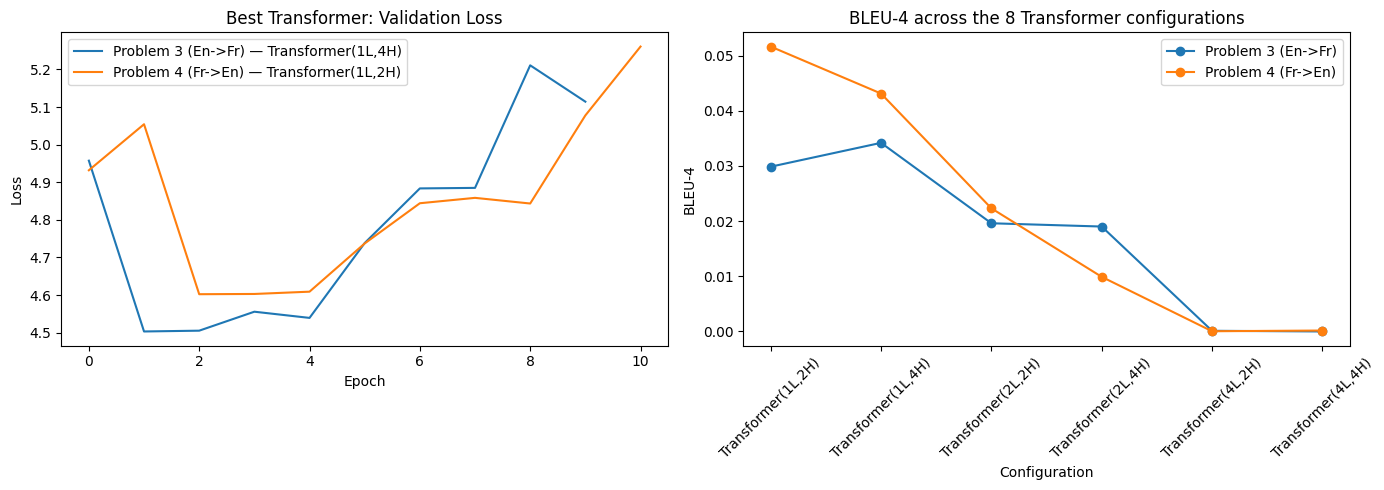

In [ ]:
# Problem 3 vs Problem 4: loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, res in [("Problem 3 (En->Fr)", problem3_results), ("Problem 4 (Fr->En)", problem4_results)]:
    best = res["best_transformer"]
    axes[0].plot(best["val_losses"], label=f"{label} — {best['config']}")
axes[0].set_title("Best Transformer: Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

for label, res in [("Problem 3 (En->Fr)", problem3_results), ("Problem 4 (Fr->En)", problem4_results)]:
    configs = [t["config"] for t in res["transformer"]]
    bleus = [t["bleu"] for t in res["transformer"]]
    axes[1].plot(configs, bleus, marker="o", label=label)
axes[1].set_title("BLEU-4 across the 8 Transformer configurations")
axes[1].set_xlabel("Configuration"); axes[1].set_ylabel("BLEU-4")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig("problem3_4_comparison.png", dpi=150)
plt.show()

In [ ]:
# comparison
p3_best = problem3_results["best_transformer"]
p4_best = problem4_results["best_transformer"]

p3_final_val = p3_best["best_val_loss"]
p4_final_val = p4_best["best_val_loss"]

better_loss_dir = "English -> French" if p3_final_val < p4_final_val else "French -> English"
better_bleu_dir = "English -> French" if p3_best["bleu"] > p4_best["bleu"] else "French -> English"
better_acc_dir = "English -> French" if p3_best["accuracy"] > p4_best["accuracy"] else "French -> English"

print("\n" + "=" * 100)
print("CONCLUDING COMPARISON — Problem 3 (En->Fr) vs Problem 4 (Fr->En)")
print("=" * 100)
print(f"Best Eng->Fr config: {p3_best['config']} | Val Loss={p3_final_val:.4f} | "
      f"Acc={p3_best['accuracy']*100:.2f}% | BLEU={p3_best['bleu']:.4f}")
print(f"Best Fr->Eng config: {p4_best['config']} | Val Loss={p4_final_val:.4f} | "
      f"Acc={p4_best['accuracy']*100:.2f}% | BLEU={p4_best['bleu']:.4f}")
print(f"""
Discussion:
  - Lower final validation loss : {better_loss_dir}
  - Higher exact-match accuracy : {better_acc_dir}
  - Higher BLEU-4 score         : {better_bleu_dir}


SyntaxError: incomplete input (1359941089.py, line 19)